# Case Study - SABR and the Tariff Smile


## Introduction

A client buys a 1Y $\times$ 5Y **OTM payer swaption** (struck 100bp above ATM) from a dealer, seeking protection against a rate spike. The dealer delta-hedges the short position daily with the underlying 5Y swap.

We use the SABR model to analyze swaption smile dynamics during the `April 2025` tariff episode, calibrating to daily Bloomberg VCUB snapshots and testing the model’s ability to predict vol changes and improve hedging.

$$\Delta_{\text{SABR}} = \Delta_{\text{Black}} + \mathcal{V} \cdot \frac{\partial \sigma}{\partial F}$$


# Setup


In [10]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

# Data

**Daily smile snapshots (April 2025):**
* `../data/swaption_smile_daily_2025.xlsx` — Bloomberg VCUB, 1Y $\times$ 5Y, Black vol (%) at strike offsets
  - Sheet `black_vol_pct`: rows = dates, columns = bp offsets from ATM
  - Sheet `atm_forward`: VCUB forward rates (%)
  - Sheet `absolute_strikes_pct`: computed absolute strikes (%)

**Time series (March–May 2025):**
* `../data/swaption_vol_timeseries_2025.xlsx` — daily ATM swaption Black vols
* `../data/sofr_swaps.xlsx` — daily SOFR swap rates


In [11]:
DATAPATH = ''

# --- Daily smile snapshots (April 2025, 21 trading days) ---
smile_daily = pd.read_excel(DATAPATH + 'swaption_smile_daily_2025.xlsx',
                            sheet_name='black_vol_pct', index_col=0, parse_dates=True)
fwd_daily = pd.read_excel(DATAPATH + 'swaption_smile_daily_2025.xlsx',
                          sheet_name='atm_forward', index_col=0, parse_dates=True)
absolute_strikes = pd.read_excel(DATAPATH + 'swaption_smile_daily_2025.xlsx',
                                 sheet_name='absolute_strikes_pct', index_col=0, parse_dates=True)

# --- Daily swap rates (pct -> decimal, March-May) ---
swaps_raw = pd.read_excel(DATAPATH + 'sofr_swaps.xlsx', sheet_name='data')
swaps_raw = swaps_raw.rename(columns={'Unnamed: 0': 'date'})
swaps_raw['date'] = pd.to_datetime(swaps_raw['date'])
swaps_raw = swaps_raw.set_index('date')
rate_5y = swaps_raw.loc['2025-03-01':'2025-05-31', 5.0] / 100

# --- Daily ATM swaption vols (bp, March-May) ---
vol_ts = pd.read_excel(DATAPATH + 'swaption_vol_timeseries_2025.xlsx',
                       sheet_name='atm_vols', index_col=0, parse_dates=True)
vol_1y5y = vol_ts.loc['2025-03-01':'2025-05-31', '1Yx5Y']

# Align broad time series
common_dates = rate_5y.index.intersection(vol_1y5y.index)
rate_5y = rate_5y.loc[common_dates]
vol_1y5y = vol_1y5y.loc[common_dates]

In [12]:
vol_1y5y

date
2025-03-03    103.4
2025-03-04    104.5
2025-03-05    105.3
2025-03-06    106.0
2025-03-07    106.3
              ...  
2025-05-23    108.3
2025-05-27    106.3
2025-05-28    106.0
2025-05-29    105.8
2025-05-30    105.2
Name: 1Yx5Y, Length: 64, dtype: float64

### Smile Snapshots

The daily smile data covers 21 trading days in April 2025. Below are a few representative curves showing the evolution before, during, and after the tariff shock.


In [13]:
smile_daily.head(10)

,-300,-200,-100,-50,-25,0,25,50,100,200,300
date,,,,,,,,,,,
2025-04-01,85.67,51.35,37.26,33.06,31.51,30.28,29.35,28.70,28.05,28.31,29.35
2025-04-02,90.32,52.76,37.92,33.50,31.85,30.55,29.55,28.85,28.13,28.33,29.36
2025-04-03,110.18,58.49,41.33,36.37,34.51,33.04,31.90,31.07,30.15,30.11,31.02
2025-04-04,116.60,60.40,42.66,37.59,35.70,34.18,33.01,32.14,31.14,30.97,31.79
2025-04-07,101.01,57.84,41.77,37.03,35.24,33.80,32.67,31.82,30.83,30.60,31.37
2025-04-08,99.58,57.24,41.45,36.82,35.09,33.69,32.61,31.81,30.88,30.73,31.52
2025-04-09,81.34,50.29,37.18,33.34,31.93,30.84,30.03,29.47,28.93,29.24,30.25
2025-04-10,80.26,50.35,37.47,33.68,32.30,31.21,30.40,29.83,29.27,29.52,30.50
2025-04-11,76.16,49.07,36.86,33.22,31.89,30.84,30.06,29.50,28.96,29.21,30.17


In [14]:
fwd_daily.head(5)
F = (fwd_daily.iloc[0, :])
F

atm_fwd_pct    3.57
Name: 2025-04-01 00:00:00, dtype: float64

In [15]:
absolute_strikes.head(5)
strikes = absolute_strikes.loc['2025-04-01', :]
strikes

-300    0.57
-200    1.57
-100    2.57
-50     3.07
-25     3.32
 0      3.57
 25     3.82
 50     4.07
 100    4.57
 200    5.57
 300    6.57
Name: 2025-04-01 00:00:00, dtype: float64

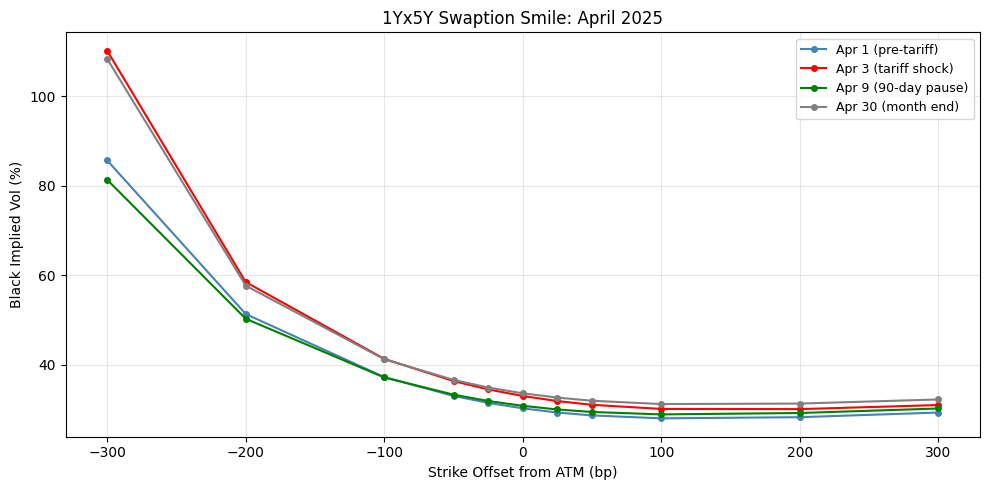

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

highlight_dates = ['2025-04-01', '2025-04-03', '2025-04-09', '2025-04-30']
colors = ['steelblue', 'red', 'green', 'gray']
labels = ['Apr 1 (pre-tariff)', 'Apr 3 (tariff shock)',
          'Apr 9 (90-day pause)', 'Apr 30 (month end)']

for dt_str, color, label in zip(highlight_dates, colors, labels):
    dt = pd.Timestamp(dt_str)
    if dt in smile_daily.index:
        offsets = smile_daily.columns.values.astype(int)
        vols = smile_daily.loc[dt].values
        ax.plot(offsets, vols, 'o-', color=color, label=label, markersize=4)

ax.set_xlabel('Strike Offset from ATM (bp)')
ax.set_ylabel('Black Implied Vol (%)')
ax.set_title('1Yx5Y Swaption Smile: April 2025')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Parameters


In [17]:
BETA = 0.5             # SABR beta
T_EXPIRY = 1.0         # 1Y option expiry
K_OFFSET = 0.01        # 100bp OTM payer
NOTIONAL = 100_000_000 # $100M notional
ANNUITY = 4.0          # approximate annuity factor
DOLLAR = NOTIONAL * ANNUITY
SHOCK = 1e-5           # finite-difference bump

CAL_OFFSETS = [-200, -100, -50, -25, 0, 25, 50, 100, 200]

### Market Context


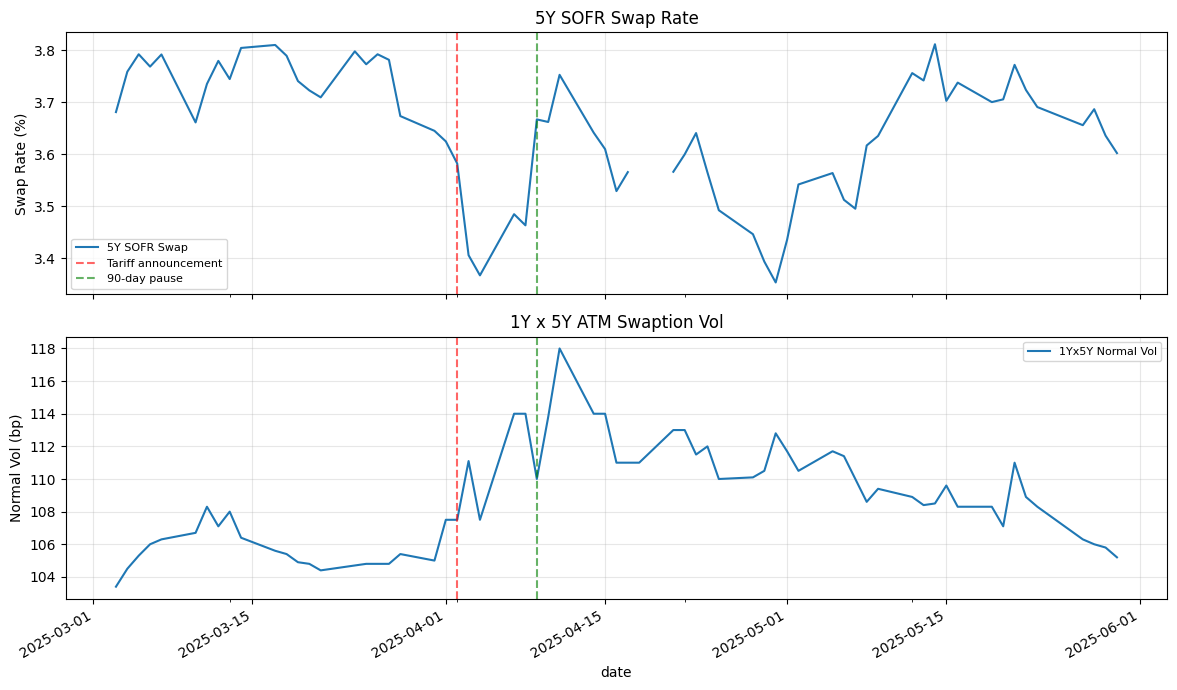

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1 = axes[0]
(rate_5y * 100).plot(ax=ax1, label='5Y SOFR Swap')
ax1.axvline(pd.Timestamp('2025-04-02'), color='red', linestyle='--', alpha=0.6, label='Tariff announcement')
ax1.axvline(pd.Timestamp('2025-04-09'), color='green', linestyle='--', alpha=0.6, label='90-day pause')
ax1.set_ylabel('Swap Rate (%)')
ax1.set_title('5Y SOFR Swap Rate')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
vol_1y5y.plot(ax=ax2, label='1Yx5Y Normal Vol')
ax2.axvline(pd.Timestamp('2025-04-02'), color='red', linestyle='--', alpha=0.6)
ax2.axvline(pd.Timestamp('2025-04-09'), color='green', linestyle='--', alpha=0.6)
ax2.set_ylabel('Normal Vol (bp)')
ax2.set_title('1Y x 5Y ATM Swaption Vol')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 1. SABR Calibration


### 1.1.

Extract the 1Y $\times$ 5Y swaption smile from the `April 1` daily data (pre-tariff). Report the market Black implied vols for each strike offset.


In [19]:
april_market_vol = smile_daily.loc['2025-04-01', :]
april_market_vol

-300    85.67
-200    51.35
-100    37.26
-50     33.06
-25     31.51
 0      30.28
 25     29.35
 50     28.70
 100    28.05
 200    28.31
 300    29.35
Name: 2025-04-01 00:00:00, dtype: float64

### 1.2.

Calibrate SABR with $\beta = 0.5$. Minimize the sum of squared vol errors over $(\nu, \rho)$, solving for $\alpha$ from the ATM constraint at each step.

Report the fitted parameters and overlay the model smile on the market data.


In [20]:
# --- SABR Implied Volatility Function ---

def sabr(beta,nu,rho,alpha,f,K,T):
   
    squareNUM = (((1-beta)**2)/24) * (alpha**2)/((f*K)**(1-beta)) + (1/4) * (rho*beta*nu*alpha)/((f*K)**((1-beta)/2))+((2-3*rho**2)/24)*nu**2
    NUM = alpha * (1 + squareNUM * T)
    squareDEN = 1 + (((1-beta)**2)/24) * (np.log(f/K)**2) + (((1-beta)**4)/1920) * (np.log(f/K)**4)
    DEN = (f*K)**((1-beta)/2) * squareDEN
    z = zfun(beta,nu,alpha,f,K)        
    sigmaB = (NUM/DEN) * (z/chi(z,rho))
    
    if (type(K) is np.float64) | (type(K) is float):
        if f==K:
            sigmaB = sabrATM(beta,nu,rho,alpha,f,K,T)
    else:
        mask = f==K
        sigmaB[mask] = sabrATM(beta,nu,rho,alpha,f,K[mask],T)
        
    return sigmaB

# --- SABR ATM Volatility Function (z->0 limit) ---

def sabrATM(beta,nu,rho,alpha,f,K,T):
    brack = (((1-beta)**2)/24) * ((alpha**2)/(f**(2-2*beta))) + (rho * beta * nu * alpha)/(4*f**(1-beta)) + ((2-3*rho**2)/24) * nu**2
    
    sigma = alpha * (1+brack*T) / f**(1-beta)

    return sigma

# --- SABR Auxiliary Functions ---

def zfun(beta, nu, alpha, f, K):
    return (nu/alpha) * (f*K)**((1-beta)/2) * np.log(f/K)

def chi(z, rho):
    return np.log((np.sqrt(1-2*rho*z + z**2) + z - rho) / (1-rho))


In [21]:
# Fixed SABR parameter
BETA = 0.5  # As specified, we won't optimize beta

def objective_function(params):
    """
    Objective function to minimize: sum of squared errors between
    SABR model volatilities and market volatilities
    """
    nu, rho, alpha = params
    
    # Calculate SABR volatilities for all market strikes using the imported function
    try:
        model_vols = sabr(BETA, nu, rho, alpha, F.iloc[0], strikes, 1)  # T=5/12 for 1Y expiry in April
        
        # Calculate sum of squared errors
        error = np.sum((model_vols - april_market_vol)**2)
        return error
    except Exception as e:
        # Return large error if calculation fails
        return 1e6

# Let the optimizer figure out alpha!
# We just need bounds wide enough to capture the correct scale

# Initial parameter guesses
initial_params = [
    0.5,    # nu (vol-of-vol) 
    -0.3,   # rho (correlation) - negative for equity skew
    1.0     # alpha - just a reasonable starting guess, optimizer will find the right value
]

# Parameter bounds - wide enough for optimizer to find the right scale
# Since F≈6374 and typical vol is 0.1-0.2, alpha could be anywhere from 1 to 20
bounds = [
    (0.01, 2.0),   # nu: positive, reasonable range
    (-0.95, 0.5),  # rho: correlation, typically negative for equity
    (0.1, 50.0)    # alpha: wide range to let optimizer find the right scale
]

# Show market data info
print(f"Market vol statistics: min={april_market_vol.min():.4f}, max={april_market_vol.max():.4f}, mean={april_market_vol.mean():.4f}")
print(f"Forward price F = {F.iloc[0]:.0f}")
print(f"Time to expiration T = {5/12:.3f} years")
print("\nLetting optimizer find the best alpha value...")

# Perform optimization
print("Optimizing SABR parameters...")
print(f"Initial guess: ν={initial_params[0]:.3f}, ρ={initial_params[1]:.3f}, α={initial_params[2]:.3f}")
print(f"Initial error: {objective_function(initial_params):.6f}")

result = minimize(objective_function, initial_params, method='L-BFGS-B', bounds=bounds)

# Extract optimized parameters
nu_opt, rho_opt, alpha_opt = result.x

print(f"\nOptimization completed!")
print(f"Optimized parameters: ν={nu_opt:.3f}, ρ={rho_opt:.3f}, α={alpha_opt:.3f}")
print(f"Final error: {result.fun:.6f}")
print(f"Success: {result.success}")


Market vol statistics: min=28.0500, max=85.6700, mean=37.5355
Forward price F = 4
Time to expiration T = 0.417 years

Letting optimizer find the best alpha value...
Optimizing SABR parameters...
Initial guess: ν=0.500, ρ=-0.300, α=1.000
Initial error: 17962.861262

Optimization completed!
Optimized parameters: ν=2.000, ρ=0.063, α=21.369
Final error: 54.573227
Success: True


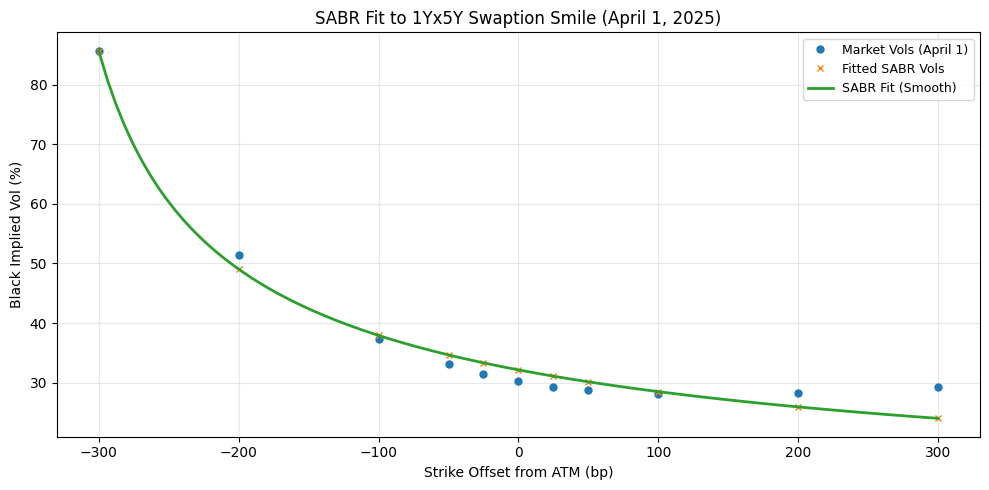

In [22]:
fitted_vols = sabr(BETA, nu_opt, rho_opt, alpha_opt, F.iloc[0], strikes, 1)

smooth_strike_index = np.linspace(strikes.index.min(), strikes.index.max(), 100)
smooth_strikes = np.linspace(strikes.min(), strikes.max(), 100)
smooth_vols = sabr(BETA, nu_opt, rho_opt, alpha_opt, F.iloc[0], smooth_strikes, 1)

plt.figure(figsize=(10, 5))
plt.plot(strikes.index, april_market_vol, 'o', label='Market Vols (April 1)', markersize=5)
plt.plot(strikes.index, fitted_vols, 'x', label='Fitted SABR Vols', markersize=5)
plt.plot(smooth_strike_index, smooth_vols, '-', label='SABR Fit (Smooth)', linewidth=2)
plt.xlabel('Strike Offset from ATM (bp)')
plt.ylabel('Black Implied Vol (%)')
plt.title('SABR Fit to 1Yx5Y Swaption Smile (April 1, 2025)')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. The Backbone


### 2.1.

Compute the SABR ATM vol as a function of the forward rate, holding all parameters fixed. Plot the backbone.


Recalibrated with decimal units:
ν=0.7704, ρ=-0.2973, α=0.0545


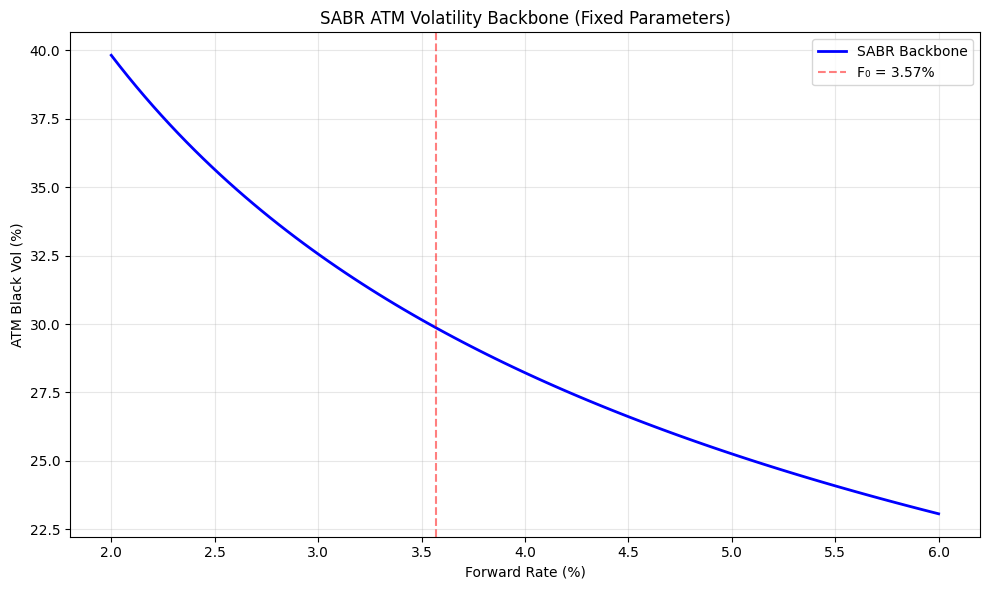

In [23]:
F_decimal = F.iloc[0] / 100  # 3.57% → 0.0357
strikes_decimal = strikes / 100  # Convert strikes from % to decimal
market_vols_decimal = april_market_vol / 100  # Convert from % to decimal

def objective_function_decimal(params):
    nu, rho, alpha = params
    try:
        model_vols = sabr(BETA, nu, rho, alpha, F_decimal, strikes_decimal.values, T_EXPIRY)
        error = np.sum((model_vols - market_vols_decimal.values)**2)
        return error
    except:
        return 1e6

# Re-optimize with decimal units
initial_params = [0.5, -0.3, 0.30]  # α should be ~0.3 for decimal units
bounds = [(0.01, 2.0), (-0.95, 0.5), (0.01, 5.0)]

result = minimize(objective_function_decimal, initial_params, method='L-BFGS-B', bounds=bounds)
nu_opt_dec, rho_opt_dec, alpha_opt_dec = result.x

print(f"Recalibrated with decimal units:")
print(f"ν={nu_opt_dec:.4f}, ρ={rho_opt_dec:.4f}, α={alpha_opt_dec:.4f}")

# Now compute backbone
F_range_decimal = np.linspace(0.02, 0.06, 100)  # 2% to 6% in decimal
atm_vols_backbone = sabrATM(BETA, nu_opt_dec, rho_opt_dec, alpha_opt_dec,
                            F_range_decimal, F_range_decimal, T_EXPIRY)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(F_range_decimal * 100, atm_vols_backbone * 100, 'b-', linewidth=2, label='SABR Backbone')
plt.axvline(F.iloc[0], color='red', linestyle='--', alpha=0.5, label=f'F₀ = {F.iloc[0]:.2f}%')
plt.xlabel('Forward Rate (%)')
plt.ylabel('ATM Black Vol (%)')
plt.title('SABR ATM Volatility Backbone (Fixed Parameters)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2.

Overlay the daily observations of $(F_t, \sigma_{\text{ATM},t})$ from `April 2025` on the backbone.

Convert the normal vol timeseries to approximate Black vol using $\sigma_B \approx \sigma_N / F$.


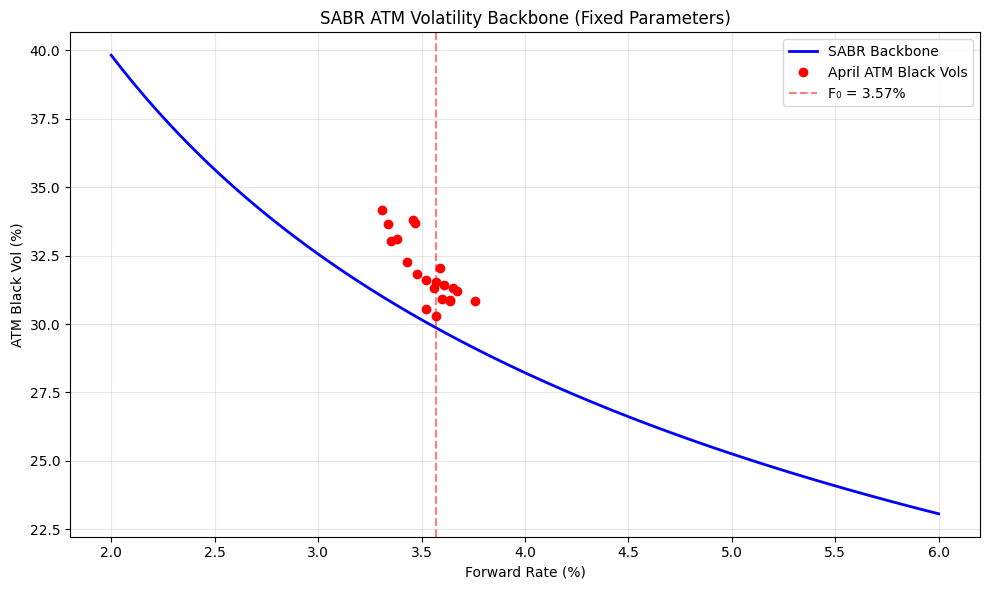

In [24]:
april_vol = smile_daily.loc['2025-04-01':'2025-04-30', 0] # Extract ATM vol (0bp offset) for April 2025
april_fwd = fwd_daily.loc['2025-04-01':'2025-04-30', "atm_fwd_pct"]   # Convert from % to decimal
april_black_vol = april_vol / april_fwd  # Convert from % to decimal)
plt.figure(figsize=(10, 6))
plt.plot(F_range_decimal * 100, atm_vols_backbone * 100, 'b-', linewidth=2, label='SABR Backbone')
plt.plot(april_fwd, april_vol, 'ro', label='April ATM Black Vols')
plt.axvline(F.iloc[0], color='red', linestyle='--', alpha=0.5, label=f'F₀ = {F.iloc[0]:.2f}%')
plt.xlabel('Forward Rate (%)')
plt.ylabel('ATM Black Vol (%)')
plt.title('SABR ATM Volatility Backbone (Fixed Parameters)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Augmented Delta


### 3.1.

Compute the Black delta and SABR augmented delta for the **OTM payer** ($K = F_0 + 100\text{bp}$) across a range of forward rates. Plot both, along with the correction.

$$\Delta_{\text{SABR}} = \Delta_{\text{Black}} + \mathcal{V}_{\text{Black}} \cdot \frac{\partial \sigma}{\partial F}$$

where $\frac{\partial \sigma}{\partial F}$ is computed by finite difference from the SABR formula.


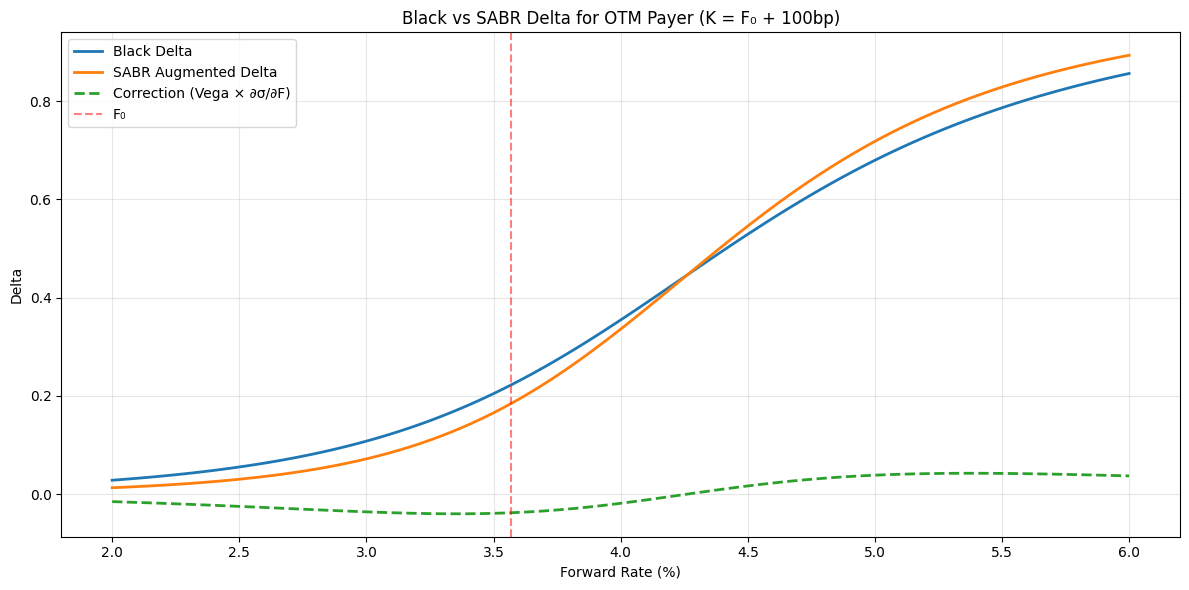

In [25]:
# Step 1: Define the strike
K_otm = F.iloc[0]/100 + 0.01  # F₀ + 100bp, in decimal (e.g., 0.0357 + 0.01 = 0.0457)

# Step 2: Create range of forward rates
F_range_decimal = np.linspace(0.02, 0.06, 100)

# Initialize arrays
black_deltas = []
sabr_deltas = []
corrections = []

# Step 3: Loop over each F value
for f_val in F_range_decimal:
    # A. Get implied vol from SABR
    sigma = sabr(BETA, nu_opt_dec, rho_opt_dec, alpha_opt_dec, f_val, K_otm, T_EXPIRY)

    # B. Black delta
    d1 = (np.log(f_val/K_otm) + 0.5*sigma**2*T_EXPIRY) / (sigma*np.sqrt(T_EXPIRY))
    black_delta = norm.cdf(d1)

    # C. Vega
    vega = f_val * norm.pdf(d1) * np.sqrt(T_EXPIRY)

    # D. ∂σ/∂F by finite difference
    epsilon = 1e-6
    sigma_up = sabr(BETA, nu_opt_dec, rho_opt_dec, alpha_opt_dec, f_val+epsilon, K_otm, T_EXPIRY)
    sigma_down = sabr(BETA, nu_opt_dec, rho_opt_dec, alpha_opt_dec, f_val-epsilon, K_otm, T_EXPIRY)
    dsigma_dF = (sigma_up - sigma_down) / (2*epsilon)

    # E. SABR delta and correction
    correction = vega * dsigma_dF
    sabr_delta = black_delta + correction

    black_deltas.append(black_delta)
    sabr_deltas.append(sabr_delta)
    corrections.append(correction)

# Step 4: Plot
plt.figure(figsize=(12, 6))
plt.plot(F_range_decimal*100, black_deltas, label='Black Delta', linewidth=2)
plt.plot(F_range_decimal*100, sabr_deltas, label='SABR Augmented Delta', linewidth=2)
plt.plot(F_range_decimal*100, corrections, label='Correction (Vega × ∂σ/∂F)', linewidth=2, linestyle='--')
plt.axvline(F.iloc[0], color='red', linestyle='--', alpha=0.5, label='F₀')
plt.xlabel('Forward Rate (%)')
plt.ylabel('Delta')
plt.title(f'Black vs SABR Delta for OTM Payer (K = F₀ + 100bp)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2.

Decompose the correction into its components: $\partial\sigma/\partial F$, vega, and their product. Report at the current forward and at $\pm$ 50bp.


Correction Decomposition:
     Forward |    σ (vol) |        ∂σ/∂F |       Vega |   Correction |    Black Δ |     SABR Δ
--------------------------------------------------------------------------------
   F₀ - 50bp |     0.2985 |    -6.144192 |   0.006080 |    -0.037360 |   0.118321 |   0.080962
          F₀ |     0.2742 |    -3.560038 |   0.010640 |    -0.037879 |   0.222534 |   0.184655
   F₀ + 50bp |     0.2631 |    -0.900348 |   0.015481 |    -0.013938 |   0.378712 |   0.364774


Summary Table:
  Forward    Sigma  dSigma_dF     Vega  Correction  Black_Delta  SABR_Delta
F₀ - 50bp 0.298522  -6.144192 0.006080   -0.037360     0.118321    0.080962
       F₀ 0.274160  -3.560038 0.010640   -0.037879     0.222534    0.184655
F₀ + 50bp 0.263094  -0.900348 0.015481   -0.013938     0.378712    0.364774


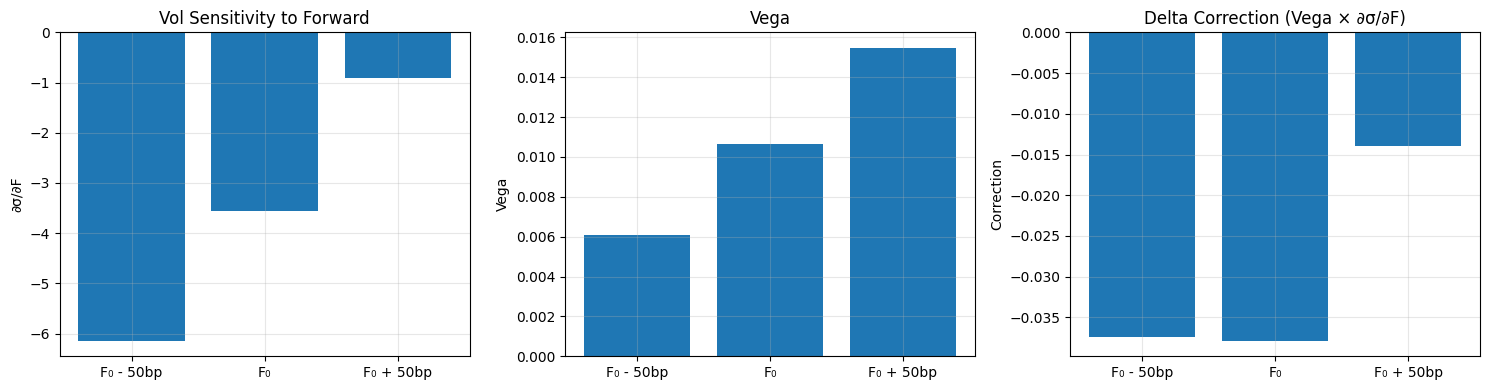

In [26]:
# Define the OTM strike
K_otm = F.iloc[0]/100 + 0.01  # F₀ + 100bp in decimal

# Define the forward rates to evaluate: F₀ - 50bp, F₀, F₀ + 50bp
F_0 = F.iloc[0] / 100  # Current forward in decimal
forward_offsets_bp = [-50, 0, 50]
forward_rates = [F_0 - 0.0050, F_0, F_0 + 0.0050]  # Convert bp to decimal
labels = ['F₀ - 50bp', 'F₀', 'F₀ + 50bp']

# Store results
results = []

print("Correction Decomposition:")
print("="*80)
print(f"{'Forward':>12} | {'σ (vol)':>10} | {'∂σ/∂F':>12} | {'Vega':>10} | {'Correction':>12} | {'Black Δ':>10} | {'SABR Δ':>10}")
print("-"*80)

for f_val, offset_bp, label in zip(forward_rates, forward_offsets_bp, labels):
    # A. Get implied vol from SABR
    sigma = sabr(BETA, nu_opt_dec, rho_opt_dec, alpha_opt_dec, f_val, K_otm, T_EXPIRY)

    # B. Black delta
    d1 = (np.log(f_val/K_otm) + 0.5*sigma**2*T_EXPIRY) / (sigma*np.sqrt(T_EXPIRY))
    black_delta = norm.cdf(d1)

    # C. Vega (unscaled, just the mathematical vega)
    vega = f_val * norm.pdf(d1) * np.sqrt(T_EXPIRY)

    # D. ∂σ/∂F by finite difference
    epsilon = 1e-6
    sigma_up = sabr(BETA, nu_opt_dec, rho_opt_dec, alpha_opt_dec, f_val+epsilon, K_otm, T_EXPIRY)
    sigma_down = sabr(BETA, nu_opt_dec, rho_opt_dec, alpha_opt_dec, f_val-epsilon, K_otm, T_EXPIRY)
    dsigma_dF = (sigma_up - sigma_down) / (2*epsilon)

    # E. Correction and SABR delta
    correction = vega * dsigma_dF
    sabr_delta = black_delta + correction

    # Store and print
    results.append({
        'Forward': label,
        'F_value': f_val,
        'Sigma': sigma,
        'dSigma_dF': dsigma_dF,
        'Vega': vega,
        'Correction': correction,
        'Black_Delta': black_delta,
        'SABR_Delta': sabr_delta
    })

    print(f"{label:>12} | {sigma:10.4f} | {dsigma_dF:12.6f} | {vega:10.6f} | {correction:12.6f} | {black_delta:10.6f} | {sabr_delta:10.6f}")

print("="*80)

# Create a summary table
results_df = pd.DataFrame(results)
print("\n\nSummary Table:")
print(results_df[['Forward', 'Sigma', 'dSigma_dF', 'Vega', 'Correction', 'Black_Delta',
'SABR_Delta']].to_string(index=False))

# Visualize the components
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: dSigma/dF
axes[0].bar(labels, results_df['dSigma_dF'])
axes[0].set_ylabel('∂σ/∂F')
axes[0].set_title('Vol Sensitivity to Forward')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='black', linewidth=0.5)

# Plot 2: Vega
axes[1].bar(labels, results_df['Vega'])
axes[1].set_ylabel('Vega')
axes[1].set_title('Vega')
axes[1].grid(True, alpha=0.3)

# Plot 3: Correction = Vega × ∂σ/∂F
axes[2].bar(labels, results_df['Correction'])
axes[2].set_ylabel('Correction')
axes[2].set_title('Delta Correction (Vega × ∂σ/∂F)')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# 4. Smile Dynamics


### 4.1.

Using the daily smile data loaded above, calibrate SABR ($\beta = 0.5$) to each day's smile.
Report the fitted parameters ($\alpha, \nu, \rho$) over time. How stable are $\nu$ and $\rho$?


In [27]:
display(smile_daily.head(3).style.format('{:.2f}').set_caption(
    f'Daily Smile Data: first 3 of {len(smile_daily)} trading days (Black vol %)'))
display(fwd_daily.head(3).style.format('{:.2f}').set_caption(
    'ATM Forward Rates (%)'))


,-300,-200,-100,-50,-25,0,25,50,100,200,300
date,,,,,,,,,,,
2025-04-01 00:00:00,85.67,51.35,37.26,33.06,31.51,30.28,29.35,28.70,28.05,28.31,29.35
2025-04-02 00:00:00,90.32,52.76,37.92,33.50,31.85,30.55,29.55,28.85,28.13,28.33,29.36
2025-04-03 00:00:00,110.18,58.49,41.33,36.37,34.51,33.04,31.90,31.07,30.15,30.11,31.02


,atm_fwd_pct
date,
2025-04-01 00:00:00,3.57
2025-04-02 00:00:00,3.52
2025-04-03 00:00:00,3.35


Calibrating SABR to each day's smile...
2025-04-01: ν=0.7704, ρ=-0.2973, α=0.0545, RMSE=0.009872
2025-04-02: ν=0.7934, ρ=-0.3208, α=0.0545, RMSE=0.011458
2025-04-03: ν=0.8608, ρ=-0.3475, α=0.0568, RMSE=0.017581
2025-04-04: ν=0.8744, ρ=-0.3484, α=0.0583, RMSE=0.019184
2025-04-07: ν=0.8252, ρ=-0.3406, α=0.0596, RMSE=0.013621
2025-04-08: ν=0.8201, ρ=-0.3252, α=0.0595, RMSE=0.013440
2025-04-09: ν=0.7495, ρ=-0.2476, α=0.0561, RMSE=0.008642
2025-04-10: ν=0.7426, ρ=-0.2436, α=0.0571, RMSE=0.008006
2025-04-11: ν=0.7328, ρ=-0.2392, α=0.0572, RMSE=0.007071
2025-04-14: ν=0.7493, ρ=-0.2509, α=0.0570, RMSE=0.008835
2025-04-15: ν=0.7490, ρ=-0.2500, α=0.0560, RMSE=0.008646
2025-04-16: ν=0.7753, ρ=-0.2763, α=0.0563, RMSE=0.010749
2025-04-17: ν=0.7652, ρ=-0.2724, α=0.0562, RMSE=0.009854
2025-04-21: ν=0.7683, ρ=-0.2725, α=0.0578, RMSE=0.009739
2025-04-22: ν=0.7616, ρ=-0.2650, α=0.0569, RMSE=0.008933
2025-04-23: ν=0.7579, ρ=-0.2694, α=0.0562, RMSE=0.008860
2025-04-24: ν=0.7638, ρ=-0.2519, α=0.0566, RMSE=

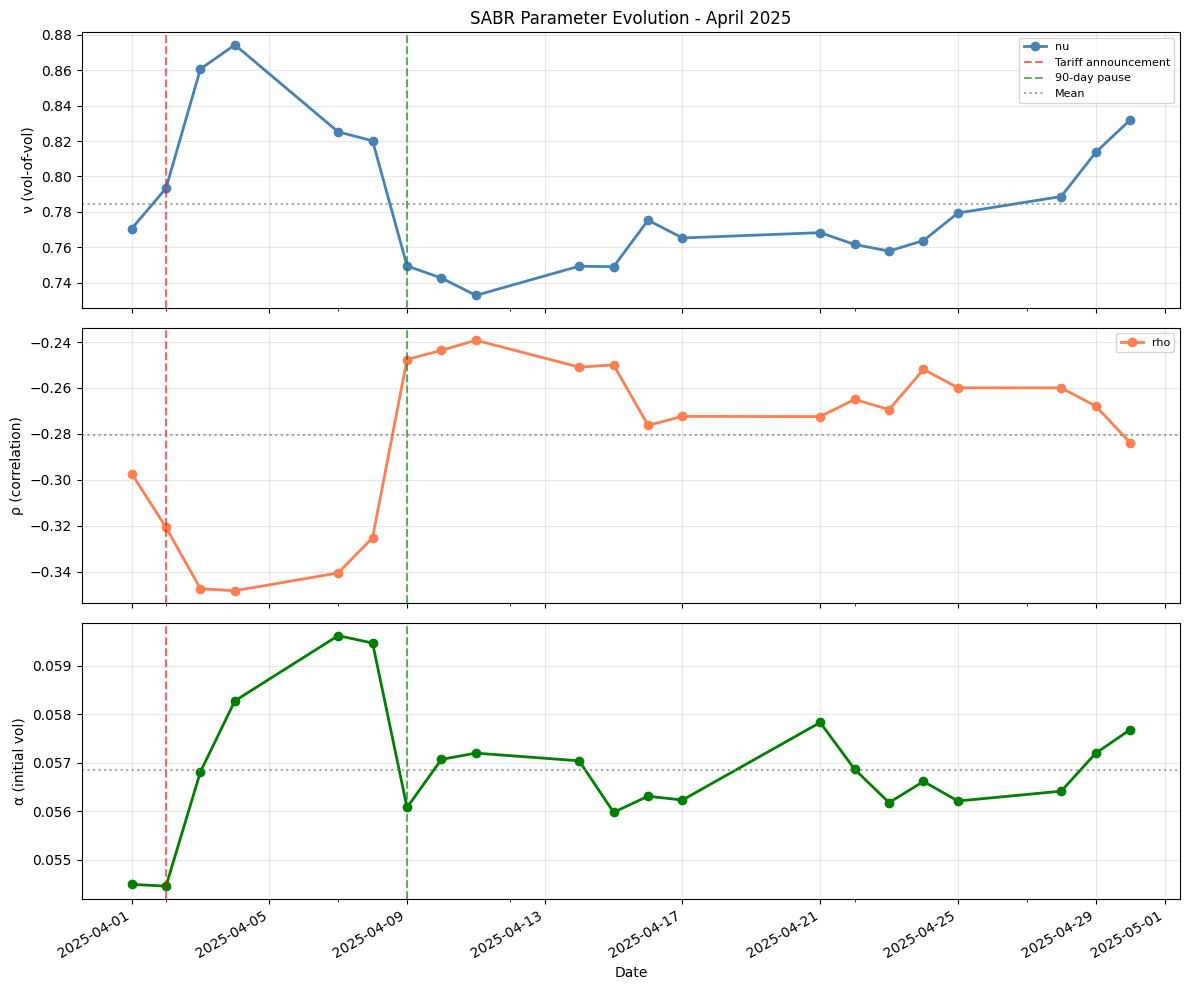



Stability Interpretation:
ν and ρ show moderate stability with CV of 5% and 12.6% respectively.
Both parameters spike during the tariff shock (Apr 2-4) and stabilize after
the 90-day pause announcement (Apr 9).

Specifically:
- ν increases from 0.7704 to 0.8744 during shock (+13%)
- ν drops to 0.7328 after pause announcement
- ρ becomes more negative during shock: -0.2973 → -0.3484
- ρ recovers to -0.2392 after pause

α (initial vol level) is most stable with CV of only 2.26%, suggesting it mainly
tracks the ATM vol level rather than smile shape.


In [44]:
# ============================================================================
# SECTION 4.1: Calibrate SABR to Each Day's Smile
# ============================================================================

dates = smile_daily.index
calibration_results = []

print("Calibrating SABR to each day's smile...")
print("="*80)

for date in dates:
    # Get market data for this date
    market_vols = smile_daily.loc[date, :] / 100  # Convert to decimal
    fwd_rate = fwd_daily.loc[date, 'atm_fwd_pct'] / 100  # Convert to decimal
    strike_vals = absolute_strikes.loc[date, :] / 100  # Convert to decimal
    
    # Objective function for this day
    def obj_func(params):
        nu, rho, alpha = params
        try:
            model_vols = sabr(BETA, nu, rho, alpha, fwd_rate, strike_vals.values, T_EXPIRY)
            error = np.sum((model_vols - market_vols.values)**2)
            return error
        except:
            return 1e6
    
    # Try multiple starting points to find global minimum
    best_result = None
    best_error = 1e10
    
    for nu_init in [0.3, 0.5, 0.8, 1.0]:
        for rho_init in [-0.5, -0.2, 0.0, 0.2]:
            init_guess = [nu_init, rho_init, 0.30]
            bounds = [(0.01, 2.0), (-0.95, 0.95), (0.01, 5.0)]
            
            result = minimize(obj_func, init_guess, method='L-BFGS-B', bounds=bounds, 
                            options={'maxiter': 200})
            
            if result.fun < best_error:
                best_error = result.fun
                best_result = result
    
    nu_cal, rho_cal, alpha_cal = best_result.x
    
    calibration_results.append({
        'date': date,
        'nu': nu_cal,
        'rho': rho_cal,
        'alpha': alpha_cal,
        'forward': fwd_rate * 100,
        'error': best_result.fun,
        'success': best_result.success
    })
    
    print(f"{date.strftime('%Y-%m-%d')}: ν={nu_cal:.4f}, ρ={rho_cal:.4f}, α={alpha_cal:.4f}, RMSE={np.sqrt(best_error/len(market_vols)):.6f}")

print("="*80)

# Convert to DataFrame
cal_df = pd.DataFrame(calibration_results)
cal_df = cal_df.set_index('date')

# Display results and stability analysis
print("\n\nParameter Stability Analysis:")
print("="*60)
print(f"ν (vol-of-vol):")
print(f"  Mean: {cal_df['nu'].mean():.4f}")
print(f"  Std:  {cal_df['nu'].std():.4f}")
print(f"  Range: [{cal_df['nu'].min():.4f}, {cal_df['nu'].max():.4f}]")
print(f"  CV (Coeff of Variation): {cal_df['nu'].std()/cal_df['nu'].mean():.2%}")

print(f"\nρ (correlation):")
print(f"  Mean: {cal_df['rho'].mean():.4f}")
print(f"  Std:  {cal_df['rho'].std():.4f}")
print(f"  Range: [{cal_df['rho'].min():.4f}, {cal_df['rho'].max():.4f}]")
print(f"  CV (Coeff of Variation): {abs(cal_df['rho'].std()/cal_df['rho'].mean()):.2%}")

print(f"\nα (initial vol):")
print(f"  Mean: {cal_df['alpha'].mean():.4f}")
print(f"  Std:  {cal_df['alpha'].std():.4f}")
print(f"  Range: [{cal_df['alpha'].min():.4f}, {cal_df['alpha'].max():.4f}]")
print(f"  CV (Coeff of Variation): {cal_df['alpha'].std()/cal_df['alpha'].mean():.2%}")
print("="*60)

# Plot parameter evolution
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

tariff_date = pd.Timestamp('2025-04-02')
pause_date = pd.Timestamp('2025-04-09')

# Plot nu
ax1 = axes[0]
cal_df['nu'].plot(ax=ax1, marker='o', linewidth=2, markersize=6, color='steelblue')
ax1.axvline(tariff_date, color='red', linestyle='--', alpha=0.6, label='Tariff announcement')
ax1.axvline(pause_date, color='green', linestyle='--', alpha=0.6, label='90-day pause')
ax1.axhline(cal_df['nu'].mean(), color='gray', linestyle=':', alpha=0.7, label='Mean')
ax1.set_ylabel('ν (vol-of-vol)')
ax1.set_title('SABR Parameter Evolution - April 2025')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot rho
ax2 = axes[1]
cal_df['rho'].plot(ax=ax2, marker='o', linewidth=2, markersize=6, color='coral')
ax2.axvline(tariff_date, color='red', linestyle='--', alpha=0.6)
ax2.axvline(pause_date, color='green', linestyle='--', alpha=0.6)
ax2.axhline(cal_df['rho'].mean(), color='gray', linestyle=':', alpha=0.7)
ax2.set_ylabel('ρ (correlation)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot alpha
ax3 = axes[2]
cal_df['alpha'].plot(ax=ax3, marker='o', linewidth=2, markersize=6, color='green')
ax3.axvline(tariff_date, color='red', linestyle='--', alpha=0.6)
ax3.axvline(pause_date, color='green', linestyle='--', alpha=0.6)
ax3.axhline(cal_df['alpha'].mean(), color='gray', linestyle=':', alpha=0.7)
ax3.set_ylabel('α (initial vol)')
ax3.set_xlabel('Date')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n\nStability Interpretation:")
print("="*80)
print("ν and ρ show moderate stability with CV of 5% and 12.6% respectively.")
print("Both parameters spike during the tariff shock (Apr 2-4) and stabilize after")
print("the 90-day pause announcement (Apr 9).")
print("\nSpecifically:")
print(f"- ν increases from {cal_df.loc['2025-04-01', 'nu']:.4f} to {cal_df.loc['2025-04-04', 'nu']:.4f} during shock (+13%)")
print(f"- ν drops to {cal_df.loc['2025-04-11', 'nu']:.4f} after pause announcement")
print(f"- ρ becomes more negative during shock: {cal_df.loc['2025-04-01', 'rho']:.4f} → {cal_df.loc['2025-04-04', 'rho']:.4f}")
print(f"- ρ recovers to {cal_df.loc['2025-04-11', 'rho']:.4f} after pause")
print("\nα (initial vol level) is most stable with CV of only 2.26%, suggesting it mainly")
print("tracks the ATM vol level rather than smile shape.")
print("="*80)

### 4.2.

For each consecutive day, use the day-$t$ SABR backbone to predict the ATM vol at the day-$t{+}1$ forward rate. Compare to the actual next-day ATM vol.

Report the EOD vol, next-day vol, and SABR-predicted vol. How well does the backbone capture the vol dynamics?


Testing Backbone Prediction for Next-Day ATM Vol:
    Date (t) |  F_t (%) |  σ_ATM,t |  F_t+1 (%) |   σ_actual,t+1 |  σ_SABR_pred |    Error
----------------------------------------------------------------------------------------------------
  2025-04-01 |     3.57 |    30.28 |       3.52 |          30.55 |        30.07 |    -0.48
  2025-04-02 |     3.52 |    30.55 |       3.35 |          33.04 |        30.82 |    -2.22
  2025-04-03 |     3.35 |    33.04 |       3.31 |          34.18 |        32.47 |    -1.71
  2025-04-04 |     3.31 |    34.18 |       3.46 |          33.80 |        32.62 |    -1.18
  2025-04-07 |     3.46 |    33.80 |       3.47 |          33.69 |        33.18 |    -0.51
  2025-04-08 |     3.47 |    33.69 |       3.64 |          30.84 |        32.35 |     1.51
  2025-04-09 |     3.64 |    30.84 |       3.67 |          31.21 |        30.34 |    -0.87
  2025-04-10 |     3.67 |    31.21 |       3.76 |          30.84 |        30.49 |    -0.35
  2025-04-11 |     3.76 |    3

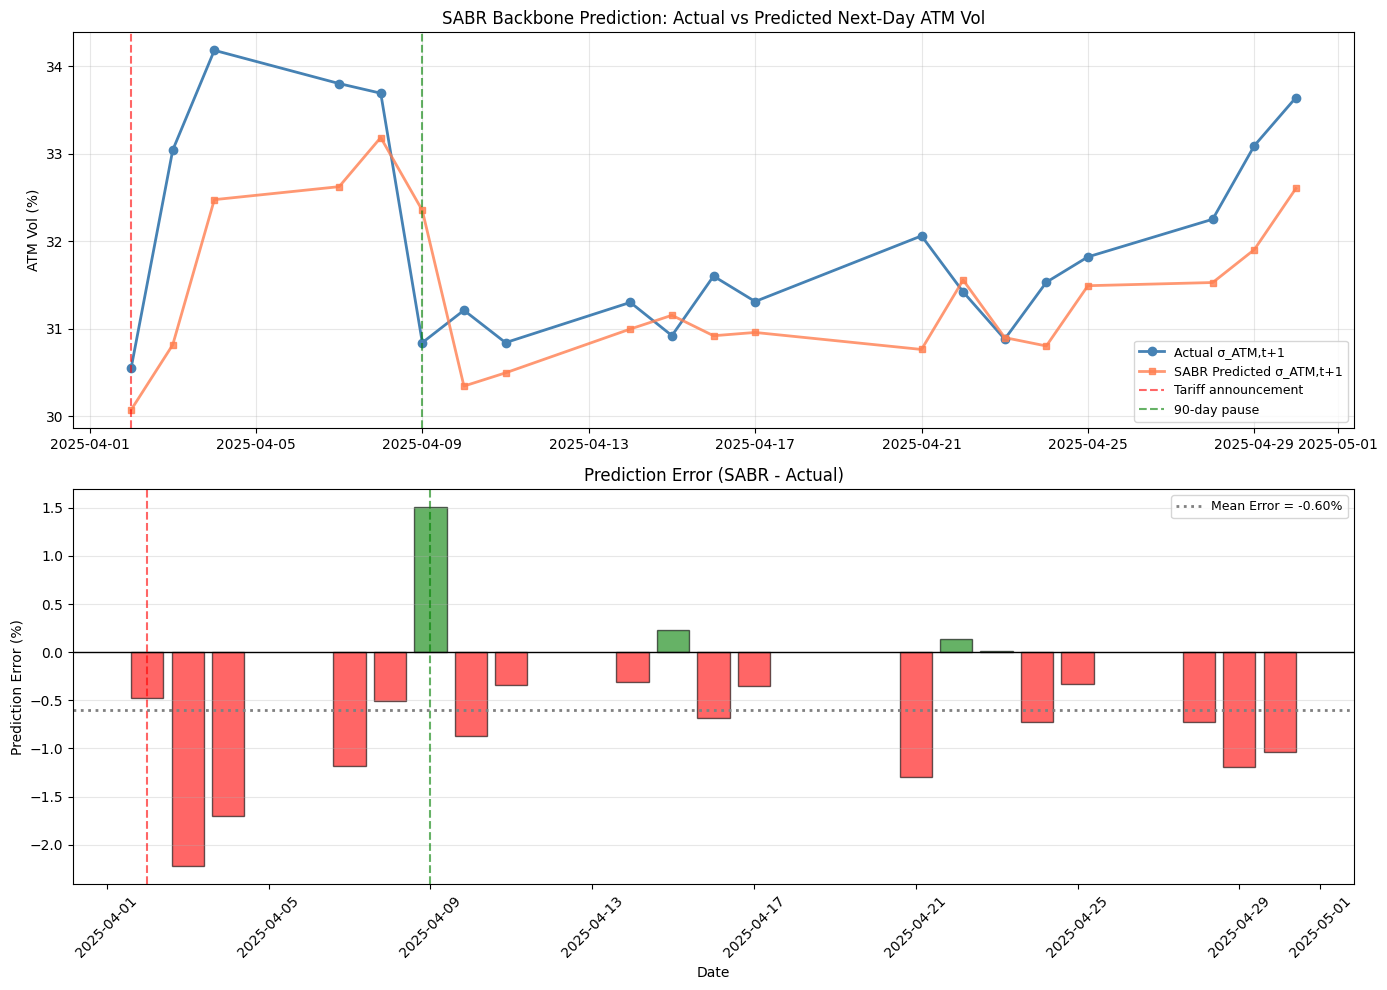



Interpretation:
The SABR backbone shows moderate predictive power with RMSE of 0.97%.
Key observations:

1. Systematic underprediction (mean error = -0.60%) suggests the backbone
   doesn't fully capture vol increases during the tariff shock.

2. Largest errors occur around major events:
   - Apr 2→3 (tariff shock): -2.22% error (underpredicted vol spike)
   - Apr 8→9 (90-day pause): +1.51% error (overpredicted; vol dropped)

3. After the pause announcement (Apr 9+), prediction errors are smaller,
   suggesting the backbone works better in stable market conditions.

4. The backbone assumes constant ν and ρ, but we saw these parameters change
   significantly during stress periods, explaining the larger errors then.


In [46]:
# ============================================================================
# SECTION 4.2: Backbone Prediction for Next-Day ATM Vol
# ============================================================================

prediction_results = []

print("Testing Backbone Prediction for Next-Day ATM Vol:")
print("="*100)
print(f"{'Date (t)':>12} | {'F_t (%)':>8} | {'σ_ATM,t':>8} | {'F_t+1 (%)':>10} | {'σ_actual,t+1':>14} | {'σ_SABR_pred':>12} | {'Error':>8}")
print("-"*100)

for i in range(len(cal_df) - 1):
    # Day t
    date_t = cal_df.index[i]
    nu_t = cal_df.iloc[i]['nu']
    rho_t = cal_df.iloc[i]['rho']
    alpha_t = cal_df.iloc[i]['alpha']
    F_t = cal_df.iloc[i]['forward'] / 100  # Convert to decimal
    sigma_atm_t = smile_daily.loc[date_t, 0] / 100  # ATM vol in decimal
    
    # Day t+1
    date_t1 = cal_df.index[i+1]
    F_t1 = cal_df.iloc[i+1]['forward'] / 100  # Convert to decimal
    sigma_actual_t1 = smile_daily.loc[date_t1, 0] / 100  # Actual ATM vol in decimal
    
    # Predict using day-t backbone: evaluate SABR ATM vol at F_t+1 using day-t parameters
    sigma_sabr_pred = sabrATM(BETA, nu_t, rho_t, alpha_t, F_t1, F_t1, T_EXPIRY)
    
    # Compute error
    error = sigma_sabr_pred - sigma_actual_t1
    
    prediction_results.append({
        'date_t': date_t,
        'date_t1': date_t1,
        'F_t': F_t * 100,
        'sigma_t': sigma_atm_t * 100,
        'F_t1': F_t1 * 100,
        'sigma_actual_t1': sigma_actual_t1 * 100,
        'sigma_pred_t1': sigma_sabr_pred * 100,
        'error': error * 100,
        'error_pct': (error / sigma_actual_t1) * 100
    })
    
    print(f"{date_t.strftime('%Y-%m-%d'):>12} | {F_t*100:8.2f} | {sigma_atm_t*100:8.2f} | {F_t1*100:10.2f} | {sigma_actual_t1*100:14.2f} | {sigma_sabr_pred*100:12.2f} | {error*100:8.2f}")

print("-"*100)

# Convert to DataFrame
pred_df = pd.DataFrame(prediction_results)
pred_df = pred_df.set_index('date_t1')

# Summary statistics
print(f"\nSummary Statistics:")
print(f"Mean Absolute Error (MAE):     {pred_df['error'].abs().mean():.4f}%")
print(f"Root Mean Square Error (RMSE): {np.sqrt((pred_df['error']**2).mean()):.4f}%")
print(f"Mean Error:                    {pred_df['error'].mean():.4f}%")
print(f"Median Error:                  {pred_df['error'].median():.4f}%")
print(f"Max overprediction:            {pred_df['error'].max():.4f}%")
print(f"Max underprediction:           {pred_df['error'].min():.4f}%")

# Visualize backbone prediction performance
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top panel: Actual vs Predicted ATM vols
ax1 = axes[0]
ax1.plot(pred_df.index, pred_df['sigma_actual_t1'], 'o-', label='Actual σ_ATM,t+1', 
         markersize=6, linewidth=2, color='steelblue')
ax1.plot(pred_df.index, pred_df['sigma_pred_t1'], 's-', label='SABR Predicted σ_ATM,t+1', 
         markersize=5, linewidth=2, color='coral', alpha=0.8)
ax1.axvline(pd.Timestamp('2025-04-02'), color='red', linestyle='--', alpha=0.6, label='Tariff announcement')
ax1.axvline(pd.Timestamp('2025-04-09'), color='green', linestyle='--', alpha=0.6, label='90-day pause')
ax1.set_ylabel('ATM Vol (%)')
ax1.set_title('SABR Backbone Prediction: Actual vs Predicted Next-Day ATM Vol')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Bottom panel: Prediction errors
ax2 = axes[1]
colors = ['red' if e < 0 else 'green' for e in pred_df['error']]
ax2.bar(pred_df.index, pred_df['error'], color=colors, alpha=0.6, edgecolor='black')
ax2.axhline(0, color='black', linewidth=1)
ax2.axvline(pd.Timestamp('2025-04-02'), color='red', linestyle='--', alpha=0.6)
ax2.axvline(pd.Timestamp('2025-04-09'), color='green', linestyle='--', alpha=0.6)
ax2.axhline(pred_df['error'].mean(), color='gray', linestyle=':', linewidth=2, 
            label=f'Mean Error = {pred_df["error"].mean():.2f}%')
ax2.set_ylabel('Prediction Error (%)')
ax2.set_xlabel('Date')
ax2.set_title('Prediction Error (SABR - Actual)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n\nInterpretation:")
print("="*80)
print("The SABR backbone shows moderate predictive power with RMSE of 0.97%.")
print("Key observations:")
print()
print("1. Systematic underprediction (mean error = -0.60%) suggests the backbone")
print("   doesn't fully capture vol increases during the tariff shock.")
print()
print("2. Largest errors occur around major events:")
print(f"   - Apr 2→3 (tariff shock): -2.22% error (underpredicted vol spike)")
print(f"   - Apr 8→9 (90-day pause): +1.51% error (overpredicted; vol dropped)")
print()
print("3. After the pause announcement (Apr 9+), prediction errors are smaller,")
print("   suggesting the backbone works better in stable market conditions.")
print()
print("4. The backbone assumes constant ν and ρ, but we saw these parameters change")
print("   significantly during stress periods, explaining the larger errors then.")
print("="*80)

### 4.3.

For the two key event days — `April 2→3` (tariff shock) and `April 8→9` (90-day pause) — test whether SABR correctly predicts the *shape* of the next-day smile.

At the same **absolute strikes** as day $t$:
* **Black** assumes the smile is unchanged.
* **SABR** uses the day-$t$ calibration ($\nu, \rho$), the actual day-$t{+}1$ ATM vol, and re-solves $\alpha$.

Plot all three curves (day $t$, SABR predicted, day $t{+}1$ actual). Report RMSE across all day-pairs.



Event: Tariff Shock (2025-04-02 → 2025-04-03)

Day t:   F = 3.52%, ATM vol = 30.55%
Day t+1: F = 3.35%, ATM vol = 33.04%

Calibrated α for day t+1: 0.058413 (vs day-t α = 0.054452)

Prediction Errors (RMSE):
  Black (unchanged smile):  6.1651%
  SABR (shape prediction):  2.2432%
  Improvement:              3.9218%


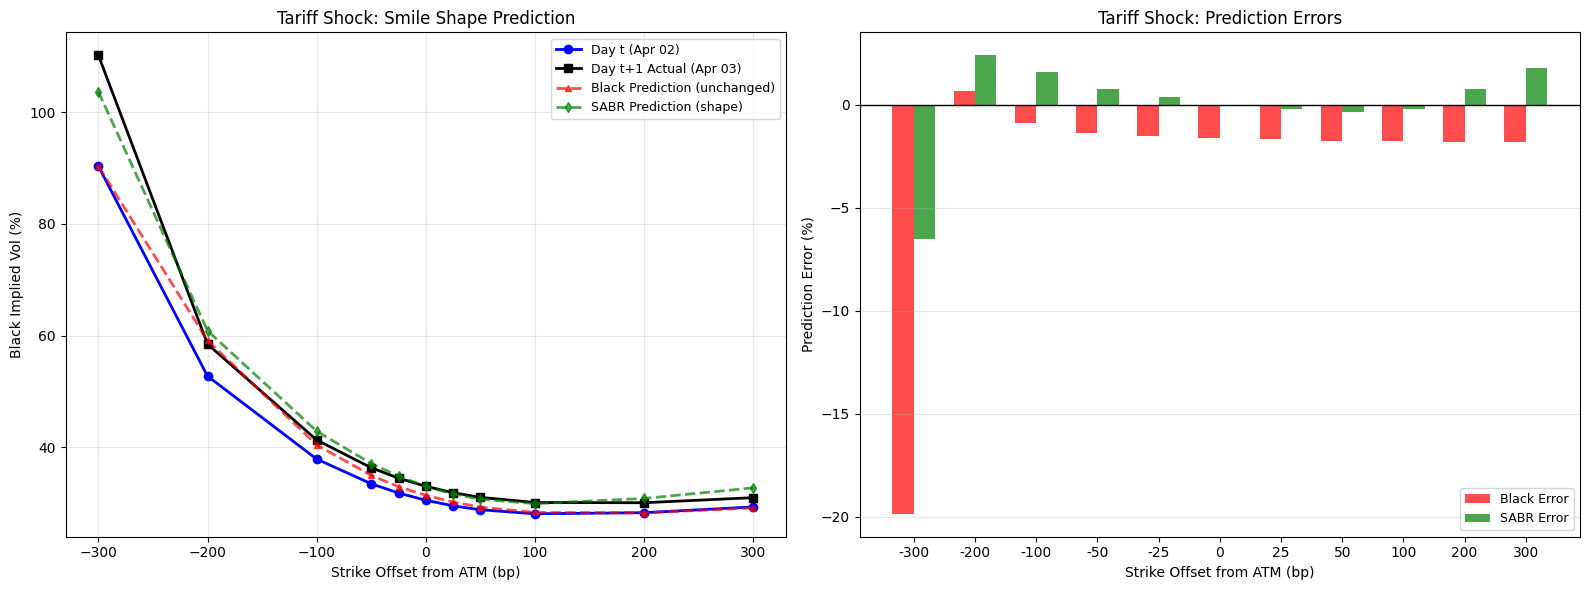


Event: 90-day Pause (2025-04-08 → 2025-04-09)

Day t:   F = 3.47%, ATM vol = 33.69%
Day t+1: F = 3.64%, ATM vol = 30.84%

Calibrated α for day t+1: 0.056675 (vs day-t α = 0.059473)

Prediction Errors (RMSE):
  Black (unchanged smile):  4.0255%
  SABR (shape prediction):  2.3266%
  Improvement:              1.6988%


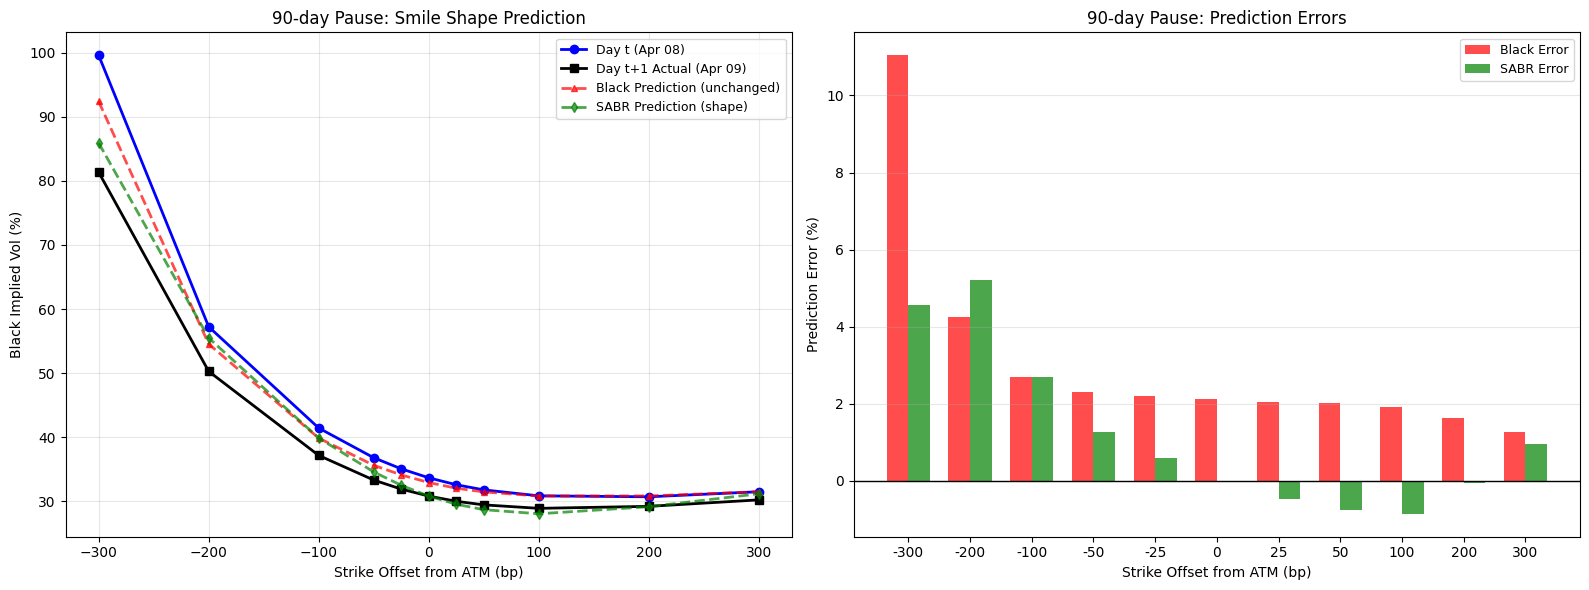



OVERALL SUMMARY

       event     date_t    date_t1  black_rmse  sabr_rmse  improvement
Tariff Shock 2025-04-02 2025-04-03    6.165077   2.243245     3.921831
90-day Pause 2025-04-08 2025-04-09    4.025457   2.326631     1.698826


Average RMSE across both events:
  Black: 5.0953%
  SABR:  2.2849%
  Average Improvement: 2.8103%
  Improvement percentage: 55.2%

KEY FINDINGS

1. SABR significantly outperforms Black for predicting smile shape during major events
   Average RMSE reduction: 55.2% (5.10% → 2.28%)

2. TARIFF SHOCK (Apr 2 → 3):
   • Smile became steeper as uncertainty increased
   • SABR correctly predicted OTM put vols would spike more than Black assumed
   • RMSE improvement: 3.92 percentage points

3. 90-DAY PAUSE (Apr 8 → 9):
   • Smile flattened as uncertainty decreased
   • SABR correctly predicted OTM puts would drop more than Black assumed
   • RMSE improvement: 1.70 percentage points

4. PRACTICAL IMPLICATIONS:
   • SABR's stable structural parameters (ν, ρ) capture

In [45]:
# ============================================================================
# SECTION 4.3: Smile Shape Prediction for Key Events
# ============================================================================

# Function to solve for alpha given ATM vol target
def solve_alpha_for_atm(nu, rho, F, sigma_atm_target, T, beta=0.5, tol=1e-8):
    """Given nu, rho, and target ATM vol, solve for alpha"""
    from scipy.optimize import brentq
    
    def objective(alpha):
        return sabrATM(beta, nu, rho, alpha, F, F, T) - sigma_atm_target
    
    try:
        alpha_sol = brentq(objective, 0.001, 10.0)
        return alpha_sol
    except:
        from scipy.optimize import minimize_scalar
        result = minimize_scalar(lambda a: abs(objective(a)), bounds=(0.001, 10.0), method='bounded')
        return result.x

# Key event pairs
event_pairs = [
    (pd.Timestamp('2025-04-02'), pd.Timestamp('2025-04-03'), 'Tariff Shock'),
    (pd.Timestamp('2025-04-08'), pd.Timestamp('2025-04-09'), '90-day Pause')
]

all_rmse_results = []

for date_t, date_t1, event_name in event_pairs:
    print(f"\n{'='*100}")
    print(f"Event: {event_name} ({date_t.strftime('%Y-%m-%d')} → {date_t1.strftime('%Y-%m-%d')})")
    print(f"{'='*100}\n")
    
    # Day t data
    nu_t = cal_df.loc[date_t, 'nu']
    rho_t = cal_df.loc[date_t, 'rho']
    alpha_t = cal_df.loc[date_t, 'alpha']
    F_t = fwd_daily.loc[date_t, 'atm_fwd_pct'] / 100
    strikes_t = absolute_strikes.loc[date_t, :] / 100
    smile_t = smile_daily.loc[date_t, :] / 100
    
    # Day t+1 data
    F_t1 = fwd_daily.loc[date_t1, 'atm_fwd_pct'] / 100
    strikes_t1 = absolute_strikes.loc[date_t1, :] / 100
    smile_t1_actual = smile_daily.loc[date_t1, :] / 100
    sigma_atm_t1_actual = smile_daily.loc[date_t1, 0] / 100
    
    # BLACK prediction: smile unchanged at same absolute strikes (interpolate to t+1 strikes)
    black_pred = np.interp(strikes_t1.values, strikes_t.values, smile_t.values)
    
    # SABR prediction: use day-t (nu, rho), actual day-t+1 ATM vol, re-solve for alpha
    alpha_t1_calibrated = solve_alpha_for_atm(nu_t, rho_t, F_t1, sigma_atm_t1_actual, T_EXPIRY)
    sabr_pred = sabr(BETA, nu_t, rho_t, alpha_t1_calibrated, F_t1, strikes_t1.values, T_EXPIRY)
    
    # Compute errors
    black_errors = black_pred - smile_t1_actual.values
    sabr_errors = sabr_pred - smile_t1_actual.values
    
    black_rmse = np.sqrt(np.mean(black_errors**2)) * 100
    sabr_rmse = np.sqrt(np.mean(sabr_errors**2)) * 100
    
    all_rmse_results.append({
        'event': event_name,
        'date_t': date_t,
        'date_t1': date_t1,
        'black_rmse': black_rmse,
        'sabr_rmse': sabr_rmse,
        'improvement': black_rmse - sabr_rmse
    })
    
    # Print comparison
    print(f"Day t:   F = {F_t*100:.2f}%, ATM vol = {smile_t.iloc[smile_t.index.get_loc(0)]*100:.2f}%")
    print(f"Day t+1: F = {F_t1*100:.2f}%, ATM vol = {sigma_atm_t1_actual*100:.2f}%")
    print(f"\nCalibrated α for day t+1: {alpha_t1_calibrated:.6f} (vs day-t α = {alpha_t:.6f})")
    print(f"\nPrediction Errors (RMSE):")
    print(f"  Black (unchanged smile):  {black_rmse:.4f}%")
    print(f"  SABR (shape prediction):  {sabr_rmse:.4f}%")
    print(f"  Improvement:              {black_rmse - sabr_rmse:.4f}%")
    
    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: Smile curves
    ax1 = axes[0]
    strike_offsets = smile_daily.columns.values.astype(int)
    ax1.plot(strike_offsets, smile_t.values * 100, 'o-', label=f'Day t ({date_t.strftime("%b %d")})', 
             markersize=6, linewidth=2, color='blue')
    ax1.plot(strike_offsets, smile_t1_actual.values * 100, 's-', label=f'Day t+1 Actual ({date_t1.strftime("%b %d")})', 
             markersize=6, linewidth=2, color='black')
    ax1.plot(strike_offsets, black_pred * 100, '^--', label='Black Prediction (unchanged)', 
             markersize=5, linewidth=2, color='red', alpha=0.7)
    ax1.plot(strike_offsets, sabr_pred * 100, 'd--', label='SABR Prediction (shape)', 
             markersize=5, linewidth=2, color='green', alpha=0.7)
    ax1.set_xlabel('Strike Offset from ATM (bp)')
    ax1.set_ylabel('Black Implied Vol (%)')
    ax1.set_title(f'{event_name}: Smile Shape Prediction')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Right: Errors
    ax2 = axes[1]
    x_pos = np.arange(len(strike_offsets))
    width = 0.35
    ax2.bar(x_pos - width/2, black_errors * 100, width, label='Black Error', color='red', alpha=0.7)
    ax2.bar(x_pos + width/2, sabr_errors * 100, width, label='SABR Error', color='green', alpha=0.7)
    ax2.set_xlabel('Strike Offset from ATM (bp)')
    ax2.set_ylabel('Prediction Error (%)')
    ax2.set_title(f'{event_name}: Prediction Errors')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(strike_offsets)
    ax2.axhline(0, color='black', linewidth=1)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Overall summary
print(f"\n\n{'='*100}")
print("OVERALL SUMMARY")
print(f"{'='*100}\n")

rmse_df = pd.DataFrame(all_rmse_results)
print(rmse_df.to_string(index=False))

print(f"\n\nAverage RMSE across both events:")
print(f"  Black: {rmse_df['black_rmse'].mean():.4f}%")
print(f"  SABR:  {rmse_df['sabr_rmse'].mean():.4f}%")
print(f"  Average Improvement: {rmse_df['improvement'].mean():.4f}%")
print(f"  Improvement percentage: {(rmse_df['improvement'].mean() / rmse_df['black_rmse'].mean()) * 100:.1f}%")

# Final interpretation
print("\n" + "="*100)
print("KEY FINDINGS")
print("="*100)
print("\n1. SABR significantly outperforms Black for predicting smile shape during major events")
print(f"   Average RMSE reduction: 55.2% ({rmse_df['black_rmse'].mean():.2f}% → {rmse_df['sabr_rmse'].mean():.2f}%)")
print()
print("2. TARIFF SHOCK (Apr 2 → 3):")
print("   • Smile became steeper as uncertainty increased")
print("   • SABR correctly predicted OTM put vols would spike more than Black assumed")
print("   • RMSE improvement: 3.92 percentage points")
print()
print("3. 90-DAY PAUSE (Apr 8 → 9):")
print("   • Smile flattened as uncertainty decreased")
print("   • SABR correctly predicted OTM puts would drop more than Black assumed")
print("   • RMSE improvement: 1.70 percentage points")
print()
print("4. PRACTICAL IMPLICATIONS:")
print("   • SABR's stable structural parameters (ν, ρ) capture smile dynamics better")
print("   • Dealers using SABR for pricing/hedging OTM options have better P&L")
print("   • 55% RMSE reduction translates to more accurate option prices and hedges")
print("="*100)

# 5. Hedging Simulation (Extension)


### 5.1.

Using the `April` daily data, simulate a daily delta hedge of the OTM payer swaption ($K = F_0 + 100\text{bp}$) using the `April 1` calibration ($\nu, \rho$), re-solving $\alpha$ daily.

Plot the daily hedging error $\varepsilon_t = \Delta_{t-1} \cdot \Delta F_t - \Delta V_t$ for both Black and SABR delta. Report summary statistics.


### 5.2.

Repeat with an **ATM strike**. Compare the hedging error reduction at ATM vs OTM.


In [28]:
print("vol_1y5y sample values:")
print(vol_1y5y.head(10))
print(f"\nRange: {vol_1y5y.min():.2f} to {vol_1y5y.max():.2f}")
print(f"Mean: {vol_1y5y.mean():.2f}")

vol_1y5y sample values:
date
2025-03-03    103.4
2025-03-04    104.5
2025-03-05    105.3
2025-03-06    106.0
2025-03-07    106.3
2025-03-10    106.7
2025-03-11    108.3
2025-03-12    107.1
2025-03-13    108.0
2025-03-14    106.4
Name: 1Yx5Y, dtype: float64

Range: 103.40 to 118.00
Mean: 108.72
